# Fast.ai Lesson 1 - Image Classification
## Key Concepts Learned:
- Transfer learning using pretrained ResNet34
- Fine-tuning on custom dataset
- Confusion matrix interpretation
- Top losses analysis for model debugging
## Results:
- 99.12% accuracy on cats vs dogs classification
- Only 13 misclassifications out of 1,478 images

In [1]:
!pip install fastai -q

In [2]:
from fastai.vision.all import *

# Download a sample dataset (pets - cats & dogs)
path = untar_data(URLs.PETS)/'images'

# Define a function to label images
def is_cat(x): return x[0].isupper()

# Create the dataset
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path),
    valid_pct=0.2,
    seed=42,
    label_func=is_cat,
    item_tfms=Resize(224)
)

# Build the model (ResNet34 pretrained)
learn = vision_learner(dls, resnet34, metrics=error_rate)

# Train for 1 epoch
learn.fine_tune(1)

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:22&lt;00:00]</div>

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 173MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.167702,0.024182,0.008796,00:42


epoch,train_loss,valid_loss,error_rate,time
0,0.060622,0.018881,0.008796,00:46


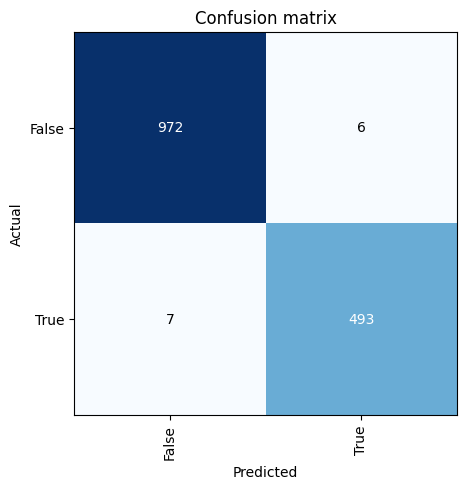

In [3]:
# See what the model gets wrong
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

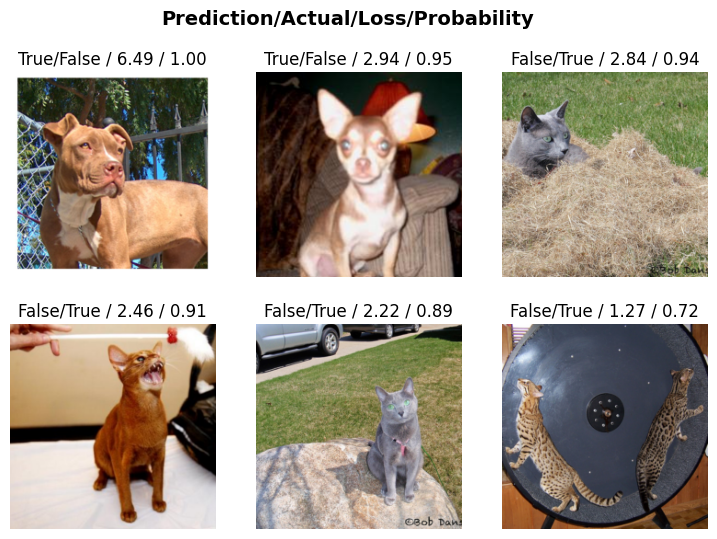

In [4]:
# See the images it was most confused about
interp.plot_top_losses(6)